<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/VanillaBCNN_Standardized_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


Using device: cuda
Beginning execution pipeline...
Files loaded successfully.
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 (DF Index: 477) | True: 1 | Pred: 1 | Confidence: 0.8690 | Uncertainty (Std): 0.0373
Sample 001 (DF Index: 837) | True: 1 | Pred: 1 | Confidence: 0.9405 | Uncertainty (Std): 0.0788
Sample 002 (DF Index: 302) | True: 1 | Pred: 1 | Confidence: 0.6562 | Uncertainty (Std): 0.1208
Sample 003 (DF Index: 405) | True: 0 | Pred: 0 | Confidence: 0.5786 | Uncertainty (Std): 0.1038
Sample 004 (DF Index: 333) | True: 1 | Pred: 1 | Confidence: 0.9308 | Uncertainty (Std): 0.0276
Sample 005 (DF Index: 332) | True: 1 | Pred: 1 | Confidence: 0.7072 | Uncertainty (Std): 0.0849
Sample 006 (DF Index: 886) | True: 0 | Pred: 0 | Confidence: 0.9007 | Uncertainty (Std): 0.0400
Sample 007 (DF Index: 730) | True: 0 | Pred: 0 | Confidence: 0.6297 | Uncertainty (Std): 0.0866
Sample 008 (DF Index: 775) | True: 0 | Pred: 1 | Confidence: 0.7117 | Uncertainty 

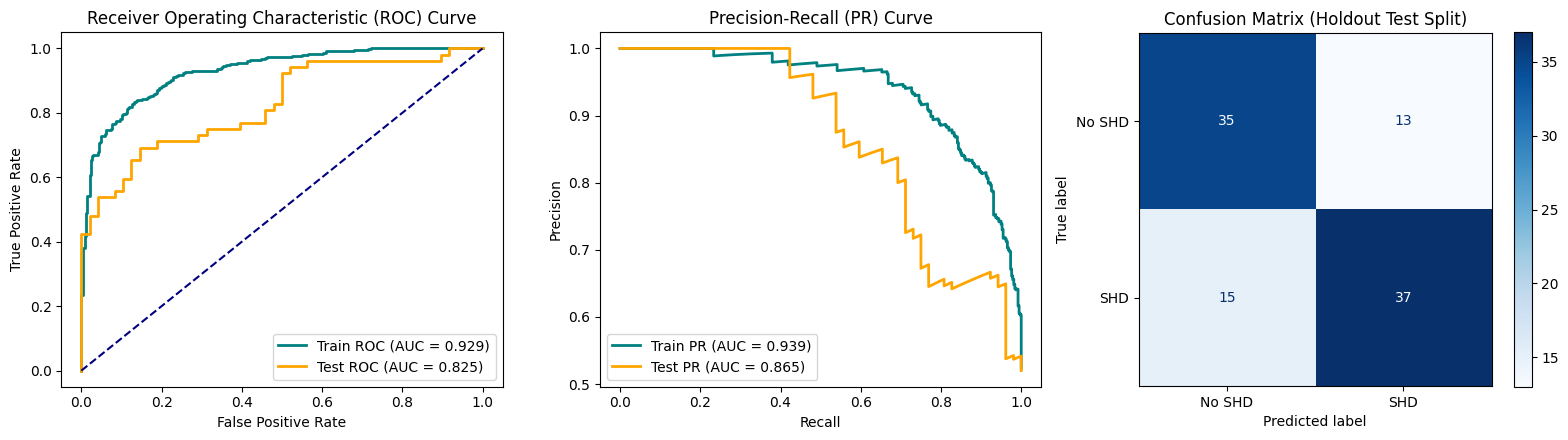

In [2]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

# Install blitz environment if not already present
try:
    from blitz.modules import BayesianLinear, BayesianConv1d
    from blitz.utils import variational_estimator
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "blitz-bayesian-pytorch"])
    from blitz.modules import BayesianLinear, BayesianConv1d
    from blitz.utils import variational_estimator

# ──────────────────────────────────────────────────────────────────────
# 0. CONFIGURATION & HYPERPARAMETERS
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Bayesian prior/posterior settings (same as the late-fusion model)
PRIOR_SIGMA_1 = 2.0
PRIOR_SIGMA_2 = 0.0025
PRIOR_PI = 1.0
POSTERIOR_RHO_INIT = -5.0

# ECG filtering settings
ECG_SAMPLING_RATE_HZ = 500
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# ──────────────────────────────────────────────────────────────────────
# 1. SIGNAL PROCESSING & SIGNAL FILTERING
# ──────────────────────────────────────────────────────────────────────
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    """Zero-phase Butterworth bandpass filter, applied along the time axis
    of a single [L, C] ECG sample."""
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)
    return filtered.astype(np.float32)

# ──────────────────────────────────────────────────────────────────────
# 2. PYTORCH DATA STRUCTURING (ECG waveform only — no demographic fusion)
# ──────────────────────────────────────────────────────────────────────
class ECGDataset(Dataset):
    def __init__(self, X_ts, y):
        assert len(X_ts) == len(y), "Length mismatch across tensor targets."
        self.X_ts = torch.tensor(X_ts, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 3. BAYESIAN NETWORK ARCHITECTURE
#    Mirrors BayesianLateFusionHeartDiseaseModel's conv backbone and head
#    exactly, minus the demographic branch:
#      conv1: in_ch -> 16, k=15, pad=7  -> BN -> ReLU -> AvgPool(10)
#      conv2: 16    -> 32, k=9,  pad=4  -> BN -> ReLU -> AvgPool(10)
#      conv3: 32    -> 32, k=5,  pad=2  -> BN -> ReLU -> GlobalAvgPool(1)
#      head : Flatten -> Linear(32, 32) -> BN -> ReLU -> Linear(32, num_classes)
# ──────────────────────────────────────────────────────────────────────
@variational_estimator
class BayesianVanillaHeartDiseaseNet(nn.Module):
    def __init__(self, sequence_length, in_channels, num_classes=2):
        super().__init__()

        def bconv(in_c, out_c, k, p):
            return BayesianConv1d(
                in_c, out_c, kernel_size=k, padding=p,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        def blinear(in_f, out_f):
            return BayesianLinear(
                in_f, out_f, prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2,
                prior_pi=PRIOR_PI, posterior_rho_init=POSTERIOR_RHO_INIT
            )

        self.conv1 = bconv(in_channels, 16, 15, 7)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.AvgPool1d(kernel_size=10)   # e.g. 2500 -> 250

        self.conv2 = bconv(16, 32, 9, 4)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.AvgPool1d(kernel_size=10)   # 250 -> 25

        self.conv3 = bconv(32, 32, 5, 2)
        self.bn3 = nn.BatchNorm1d(32)
        self.gap = nn.AdaptiveAvgPool1d(1)          # 25 -> 1

        self.relu = nn.ReLU()

        self.fc_out1 = blinear(32, 32)
        self.bn_out = nn.BatchNorm1d(32)
        self.fc_out2 = blinear(32, num_classes)

    def forward(self, x_ts):
        x = self.relu(self.bn1(self.conv1(x_ts)))
        x = self.pool1(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.gap(x)
        x = torch.flatten(x, start_dim=1)

        out = self.relu(self.bn_out(self.fc_out1(x)))
        out = self.fc_out2(out)
        return out

# ──────────────────────────────────────────────────────────────────────
# 4. TRAINING ROUTINE
#    Same optimizer, learning rate, weight decay, scheduler, epochs, and
#    sample_nbr as the late-fusion training routine.
# ──────────────────────────────────────────────────────────────────────
def train_bayesian_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4, sample_nbr=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    n_train = len(train_loader.dataset)

    for epoch in range(epochs):
        model.train()
        for X_ts_b, y_b in train_loader:
            X_ts_b, y_b = X_ts_b.to(device), y_b.to(device)
            X_ts_b += 0.05 * torch.randn_like(X_ts_b)  # light input noise, same as late-fusion training

            optimizer.zero_grad()
            nll = 0.0
            for _ in range(sample_nbr):
                logits = model(X_ts_b)
                nll += criterion(logits, y_b)

            loss = (nll / sample_nbr) + (model.nn_kl_divergence() / n_train)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_ts_v, y_v in val_loader:
                X_ts_v, y_v = X_ts_v.to(device), y_v.to(device)
                probs_accum = sum(torch.softmax(model(X_ts_v), dim=1) for _ in range(10)) / 10
                val_loss += criterion(torch.log(probs_accum + 1e-8), y_v).item() * X_ts_v.shape[0]
                val_total += X_ts_v.shape[0]

        scheduler.step(val_loss / val_total)

# ──────────────────────────────────────────────────────────────────────
# 5. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def get_predictions_and_labels(model, loader, sample_nbr=50):
    model.eval()
    all_probs, all_labels = [], []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for X_ts_b, y_b in loader:
            X_ts_b = X_ts_b.to(device)
            pass_logits = torch.stack([model(X_ts_b) for _ in range(sample_nbr)], dim=0)
            pass_probs = torch.softmax(pass_logits, dim=-1)
            mean_probs = pass_probs.mean(dim=0)

            all_nll += criterion(torch.log(mean_probs + 1e-8), y_b.to(device)).item()
            all_probs.extend(mean_probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_labels), all_nll / len(loader.dataset)

def generate_and_display_comparative_metrics(model, train_loader, test_loader, sample_nbr=50):
    train_probs, train_labels, train_nll = get_predictions_and_labels(model, train_loader, sample_nbr)
    test_probs, test_labels, test_nll = get_predictions_and_labels(model, test_loader, sample_nbr)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 6. EXECUTION PIPELINE
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Beginning execution pipeline...")

    ecg_path = 'ECG_waveforms_1K.npy'
    echo_path = 'EchoNext_EchoData_5K.csv'

    X_raw, echo_df = None, None
    max_retries, retry_delay = 5, 5

    for attempt in range(max_retries):
        try:
            if not os.path.exists(ecg_path) or not os.path.exists(echo_path):
                raise FileNotFoundError("Required files missing from workspace.")
            X_raw = np.load(ecg_path)[:1000]
            echo_df = pd.read_csv(echo_path).iloc[:1000].reset_index(drop=True)
            print("Files loaded successfully.")
            break
        except Exception as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed: {e}. Retrying...")
            time.sleep(retry_delay)
    else:
        raise RuntimeError("Failed to load required data files after multiple retries.")

    y_raw = echo_df['shd_moderate_or_greater_flag'].to_numpy()

    # ── Waveform pre-filtering ──
    X_filtered = np.array([bandpass_filter_ecg(x, fs=250) for x in X_raw])
    X_ts = np.swapaxes(X_filtered, 1, 2)  # -> [N, in_channels, sequence_length]

    # ── Dataset partitioning: 10% test, remaining 90% split 80/20 train/val ──
    total_indices = np.arange(len(y_raw))
    rem_indices, test_indices = train_test_split(
        total_indices, test_size=0.10, random_state=RANDOM_SEED, stratify=y_raw
    )
    train_indices, val_indices = train_test_split(
        rem_indices, test_size=0.20, random_state=RANDOM_SEED, stratify=y_raw[rem_indices]
    )

    X_ts_train, X_ts_val, X_ts_test = X_ts[train_indices], X_ts[val_indices], X_ts[test_indices]
    y_train, y_val, y_test = y_raw[train_indices], y_raw[val_indices], y_raw[test_indices]

    train_loader = DataLoader(ECGDataset(X_ts_train, y_train), batch_size=32, shuffle=False)
    val_loader = DataLoader(ECGDataset(X_ts_val, y_val), batch_size=128, shuffle=False)
    test_loader = DataLoader(ECGDataset(X_ts_test, y_test), batch_size=128, shuffle=False)

    # ── Initialize & train the model ──
    model = BayesianVanillaHeartDiseaseNet(
        sequence_length=X_ts.shape[2], in_channels=X_ts.shape[1], num_classes=2
    )

    print("Training model...")
    train_bayesian_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4)

    torch.manual_seed(RANDOM_SEED)

    # ── Per-sample inference on the held-out test set ──
    print("\n===== Individual Test Sample Inference Profiles ====")
    model.eval()
    sample_counter = 0

    with torch.no_grad():
        for X_ts_b, y_b in test_loader:
            X_ts_b = X_ts_b.to(device)
            pass_logits = torch.stack([model(X_ts_b) for _ in range(50)], dim=0)
            pass_probs = torch.softmax(pass_logits, dim=-1).cpu().numpy()

            mean_probs = pass_probs.mean(axis=0)
            std_probs = pass_probs.std(axis=0)

            for idx in range(X_ts_b.size(0)):
                true_val = y_b[idx].item()
                pred_val = np.argmax(mean_probs[idx])
                confidence = mean_probs[idx][pred_val]
                uncertainty = std_probs[idx][pred_val]
                global_df_idx = test_indices[sample_counter]

                print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | "
                      f"True: {true_val} | Pred: {pred_val} | "
                      f"Confidence: {confidence:.4f} | Uncertainty (Std): {uncertainty:.4f}")
                sample_counter += 1

    # ── System metrics analysis & visualizations ──
    generate_and_display_comparative_metrics(model, train_loader, test_loader, sample_nbr=50)